# IN4640 — Assignment 02 (Fitting & Alignment)

In [27]:
%pip install numpy matplotlib scikit-learn opencv-python

Note: you may need to restart the kernel to use updated packages.


In [28]:

import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.linear_model import RANSACRegressor
from pathlib import Path

BASE = Path('.')
LINES_CSV    = BASE / "Resources" / "lines.csv"
EARRINGS_IMG = BASE / "Resources" / "earrings.jpg"
TURF_IMG     = BASE / "Resources" / "turf.jpg"


## 1.(a) Total Least Squares

We fit the line in implicit form:

\[ ax + by + c = 0 \]

TLS finds the normal vector \([a, b]\) as the eigenvector associated with the **smallest eigenvalue** of the scatter matrix of centered points.

In [29]:
# Load data
D = np.genfromtxt(LINES_CSV, delimiter=',', skip_header=1)

x1 = D[:, 0]
y1 = D[:, 3]
P = np.column_stack([x1, y1])

# TLS
centroid = P.mean(axis=0)
Q = P - centroid
C = Q.T @ Q  # 2x2 scatter matrix

eigvals, eigvecs = np.linalg.eig(C)
normal = eigvecs[:, np.argmin(eigvals)]  # [a, b]
a, b = normal
c = -(a*centroid[0] + b*centroid[1])

# normalize for nicer printing
norm = np.sqrt(a*a + b*b)
a, b, c = a/norm, b/norm, c/norm

print('TLS line parameters:')
print(f'a={a:.6f}, b={b:.6f}, c={c:.6f}')


TLS line parameters:
a=-0.773562, b=0.633721, c=3.794192


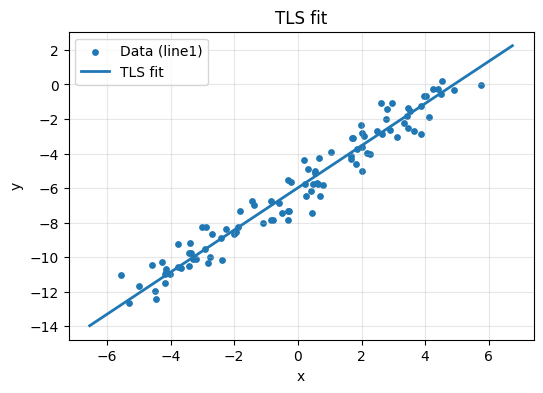

In [30]:
# Plot TLS result
xmin, xmax = x1.min()-1, x1.max()+1
xs = np.linspace(xmin, xmax, 200)

if abs(b) > 1e-9:
    ys = (-a*xs - c)/b
    plt.figure(figsize=(6,4))
    plt.scatter(x1, y1, s=15, label='Data (line1)')
    plt.plot(xs, ys, linewidth=2, label='TLS fit')
    plt.xlabel('x'); plt.ylabel('y'); plt.title('TLS fit')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()


## 1.(b) RANSAC

We flatten the 3 columns of x and y to one set of points and repeatedly run RANSAC three times:
1) fit a line, collect inliers
2) remove inliers
3) repeat to get 3 lines.

In [31]:
# Prepare points
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten().reshape(-1, 1)
Y_all = Y_cols.flatten()

remaining_X = X_all.copy()
remaining_Y = Y_all.copy()

lines = []
inlier_sets = []

for k in range(3):
    ransac = RANSACRegressor(
        min_samples=2,
        residual_threshold=None,
        random_state=42+k
    )
    ransac.fit(remaining_X, remaining_Y)
    inlier_mask = ransac.inlier_mask_
    
    m = float(ransac.estimator_.coef_[0])
    b0 = float(ransac.estimator_.intercept_)
    lines.append((m, b0))
    inlier_sets.append((remaining_X[inlier_mask].copy(), remaining_Y[inlier_mask].copy()))
    
    remaining_X = remaining_X[~inlier_mask]
    remaining_Y = remaining_Y[~inlier_mask]

print('Detected lines (y = m x + b):')
for i, (m, b0) in enumerate(lines, 1):
    print(f'Line {i}: y = {m:.6f} x + {b0:.6f}')
print('Remaining points after 3 fits:', len(remaining_X))


Detected lines (y = m x + b):
Line 1: y = -0.463283 x + 1.944594
Line 2: y = -0.153271 x + -3.327881
Line 3: y = 2.071539 x + -3.581040
Remaining points after 3 fits: 14


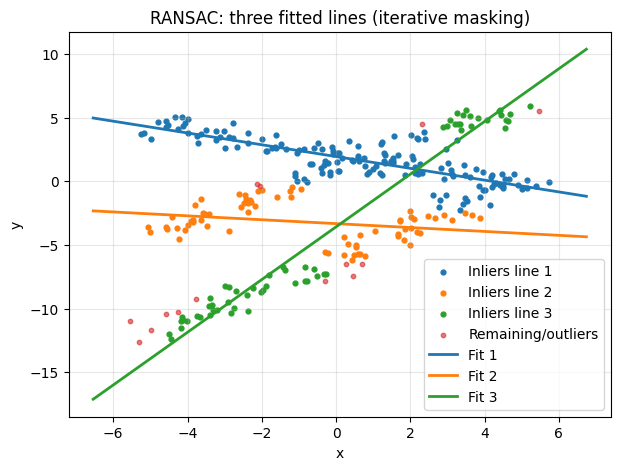

In [32]:
# Plot 
plt.figure(figsize=(7,5))

for i, (Xi, Yi) in enumerate(inlier_sets, 1):
    plt.scatter(Xi.flatten(), Yi, s=12, label=f'Inliers line {i}')

if len(remaining_X) > 0:
    plt.scatter(remaining_X.flatten(), remaining_Y, s=10, label='Remaining/outliers', alpha=0.6)

xs = np.linspace(X_all.min()-1, X_all.max()+1, 200)
for i, (m, b0) in enumerate(lines, 1):
    plt.plot(xs, m*xs + b0, linewidth=2, label=f'Fit {i}')

plt.xlabel('x'); plt.ylabel('y')
plt.title('RANSAC: three fitted lines (iterative masking)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 2) Earring size estimation from camera geometry

Given:
- focal length f = 8 mm
- pixel size = 0.0022 mm
- distance to object plane Z = 720 mm

In [33]:
# Compute mm per pixel
f_mm = 8.0
Z_mm = 720.0
pixel_mm = 0.0022

mm_per_px = (Z_mm / f_mm) * pixel_mm
print('mm_per_px =', mm_per_px)


mm_per_px = 0.198


Detected circles: 2
Best circle: center=(731,507), r=191px
Diameter: 382.00 px
Estimated real diameter: 75.64 mm (7.56 cm)


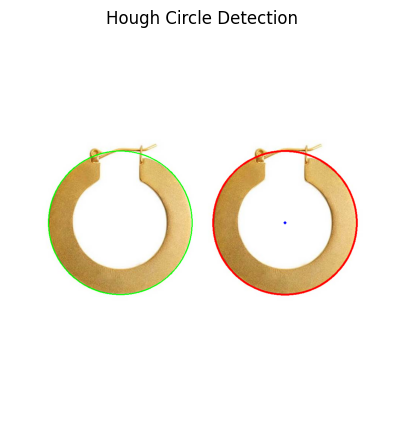

In [34]:
# --- load image ---
img = cv2.imread(str(EARRINGS_IMG))
if img is None:
    raise FileNotFoundError("earrings.jpg not found")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# --- preprocessing ---
gray_blur = cv2.GaussianBlur(gray, (9, 9), 2)


# --- Hough Circles ---
circles = cv2.HoughCircles(
    gray_blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,            # accumulator resolution (1.0–1.5)
    minDist=80,        # minimum distance between circle centers
    param1=120,        # Canny high threshold (edge detector)
    param2=40,         # accumulator threshold (lower => more circles)
    minRadius=30,      
    maxRadius=300      
)

out = img.copy()

if circles is None:
    print("No circles detected.")
else:
    circles = np.round(circles[0]).astype(int)  # (x, y, r)
    print("Detected circles:", circles.shape[0])

    # pick the largest circle (often outer ring of an earring)
    circles_sorted = sorted(circles, key=lambda c: c[2], reverse=True)
    best = circles_sorted[0]
    x, y, r = best

    # draw all circles faintly (optional)
    for (cx, cy, cr) in circles_sorted[:10]:
        cv2.circle(out, (cx, cy), cr, (0, 255, 0), 2)

    # highlight chosen circle
    cv2.circle(out, (x, y), r, (0, 0, 255), 3)
    cv2.circle(out, (x, y), 2, (255, 0, 0), 3)

    diameter_px = 2 * r
    diameter_mm = diameter_px * mm_per_px
    diameter_cm = diameter_mm / 10.0

    print(f"Best circle: center=({x},{y}), r={r}px")
    print(f"Diameter: {diameter_px:.2f} px")
    print(f"Estimated real diameter: {diameter_mm:.2f} mm ({diameter_cm:.2f} cm)")


plt.figure(figsize=(8,5))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Hough Circle Detection")
plt.show()

## 3) Homography

In [35]:

img = cv2.imread(str(TURF_IMG))
if img is None:
    raise FileNotFoundError('turf.jpg not found')

img_display = img.copy()
points = []

def mouse_callback(event, x, y, flags, param):
    global points, img_display
    if event == cv2.EVENT_LBUTTONDOWN and len(points) < 4:
        points.append((x, y))
        cv2.circle(img_display, (x, y), 6, (0, 0, 255), -1)
        cv2.imshow("turf", img_display)
        if len(points) == 4:
            print("Four points selected:", points)
            print("Press any key to continue.")

cv2.namedWindow("turf")
cv2.setMouseCallback("turf", mouse_callback)
cv2.imshow("turf", img_display)
cv2.waitKey(0)
cv2.destroyAllWindows()

points = np.array(points, dtype=np.float32)
print(points)


Four points selected: [(689, 162), (842, 161), (1242, 557), (223, 560)]
Press any key to continue.
[[ 689.  162.]
 [ 842.  161.]
 [1242.  557.]
 [ 223.  560.]]


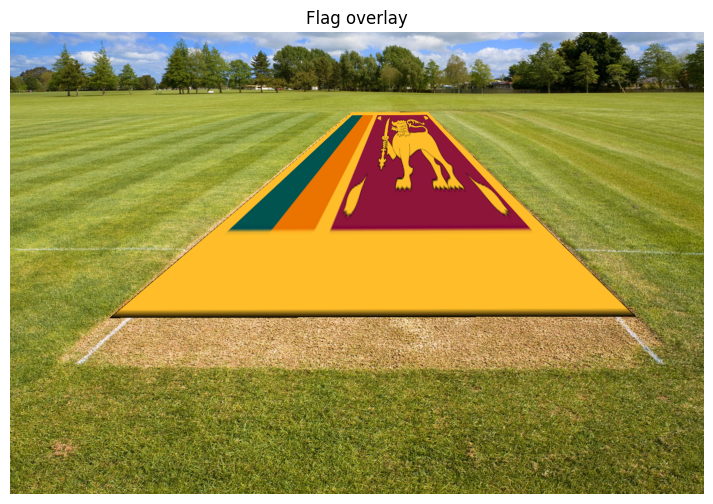

In [36]:
# Warp flag and overlay
FLAG_PATH = Path('flag.png')  
flag = cv2.imread(str(FLAG_PATH), cv2.IMREAD_COLOR)
if flag is None:
    raise FileNotFoundError('Flag image not found. Put flag.png in this folder or change FLAG_PATH.')

dst_pts = points
h, w = flag.shape[:2]
src_pts = np.array([[0,0], [w-1,0], [w-1,h-1], [0,h-1]], dtype=np.float32)

H, _ = cv2.findHomography(src_pts, dst_pts)
warped = cv2.warpPerspective(flag, H, (img.shape[1], img.shape[0]))

mask = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY) > 0
result = img.copy()
result[mask] = warped[mask]

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Flag overlay')
plt.show()
